### Importação das bibliotecas

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

### Carregamento dos dados

In [14]:
df_vendas   = pd.read_csv('../data/processed/vendas_2023_2024_processed.csv')
df_produtos = pd.read_csv('../data/processed/produtos_processed.csv')

In [15]:
df_vendas.head(5)

,id,id_client,id_product,qtd,total,sale_date,cambio
0,0,42,105,11,3405.0,2023-09-10,4.9835
1,1,3,136,9,16873.9,2024-09-15,5.5717
2,2,25,139,7,9475.3,2024-08-13,5.4875
3,4,20,23,5,55893.0,2023-02-03,5.1030
4,5,8,57,4,451403.9,2024-02-12,4.9717


In [16]:
df_produtos.head(5)

,code,name,price,actual_category
0,1,Transponder AIS Maré Magnum,33122.52,eletrônicos
1,2,Transponder Furuno Marlin,13998.15,eletrônicos
2,3,Radar Furuno Pulse Leviathan,9024.19,eletrônicos
3,4,Rádio AIS Hydro Tidal Zen,3381.88,eletrônicos
4,5,Piloto Automático Furuno Storm,23669.01,eletrônicos


join nas tabelas para ter as vendas e as categorias

In [17]:
df = df_vendas.merge(
    df_produtos[['code', 'actual_category']],
    left_on='id_product',
    right_on='code',
    how='left'
).drop(columns='code')

df.head()

,id,id_client,id_product,qtd,total,sale_date,cambio,actual_category
0,0,42,105,11,3405.0,2023-09-10,4.9835,ancoragem
1,1,3,136,9,16873.9,2024-09-15,5.5717,ancoragem
2,2,25,139,7,9475.3,2024-08-13,5.4875,ancoragem
3,4,20,23,5,55893.0,2023-02-03,5.1030,eletrônicos
4,5,8,57,4,451403.9,2024-02-12,4.9717,propulsão


### Clientes e informações

agrupar por clientes para obter as informaçoes solicitadas como faturamento total, frequencia e diversidade de categoria

In [18]:
df_clientes = df.groupby('id_client').agg(
  faturamento_total = ('total', 'sum'),
  frequencia = ('id_client', 'count'),
  diversidade_categorias = ('actual_category', 'nunique')
).reset_index()

df_clientes['ticket_medio'] = df_clientes['faturamento_total'] / df_clientes['frequencia']

df_clientes.head()

,id_client,faturamento_total,frequencia,diversidade_categorias,ticket_medio
0,1,51092500.05,190,3,268907.895000
1,2,65652931.35,220,3,298422.415227
2,3,59575349.10,207,3,287803.618841
3,4,50691754.40,207,3,244887.702415
4,5,58592802.70,202,3,290063.379703


selecionar a elite, apenas os melhores clientes de acordo com o que foi passado

In [19]:
df_elite = df_clientes[df_clientes['diversidade_categorias'] >= 3]

top10 = df_elite.sort_values(
    ['ticket_medio', 'id_client'],
    ascending=[False, True]
).head(10).reset_index(drop=True)

top10

,id_client,faturamento_total,frequencia,diversidade_categorias,ticket_medio
0,47,64003343.75,190,3,336859.703947
1,42,72187369.50,222,3,325168.331081
2,9,66788855.35,218,3,306370.896101
3,22,59581398.75,198,3,300916.155303
4,2,65652931.35,220,3,298422.415227
5,28,60826837.25,204,3,298170.770833
6,46,59126834.35,199,3,297119.770603
7,38,57093331.15,195,3,292786.313590
8,36,62791038.15,215,3,292051.340233
9,5,58592802.70,202,3,290063.379703


In [25]:
faturamento_top10 = top10["faturamento_total"].sum()

print(f"Faturamento total desses top 10 clientes é R$ {faturamento_top10:.2f}")

Faturamento total desses top 10 clientes é R$ 626644742.30


verificar a categoria dominante dos clientes

In [21]:
ids_client_top10 = top10['id_client'].tolist()

df_top10_vendas = df[df['id_client'].isin(ids_client_top10)]

categoria_dominante = df_top10_vendas.groupby('actual_category')['qtd'].sum().sort_values(ascending=False)

print("Quantidade de itens comprados de cada categoria (categoria dominante dos top10):")
print(categoria_dominante)

Quantidade de itens comprados de cada categoria (categoria dominante dos top10):
actual_category
propulsão      6030
ancoragem      5632
eletrônicos    5214
Name: qtd, dtype: int64


### Analise Visual de Clientes

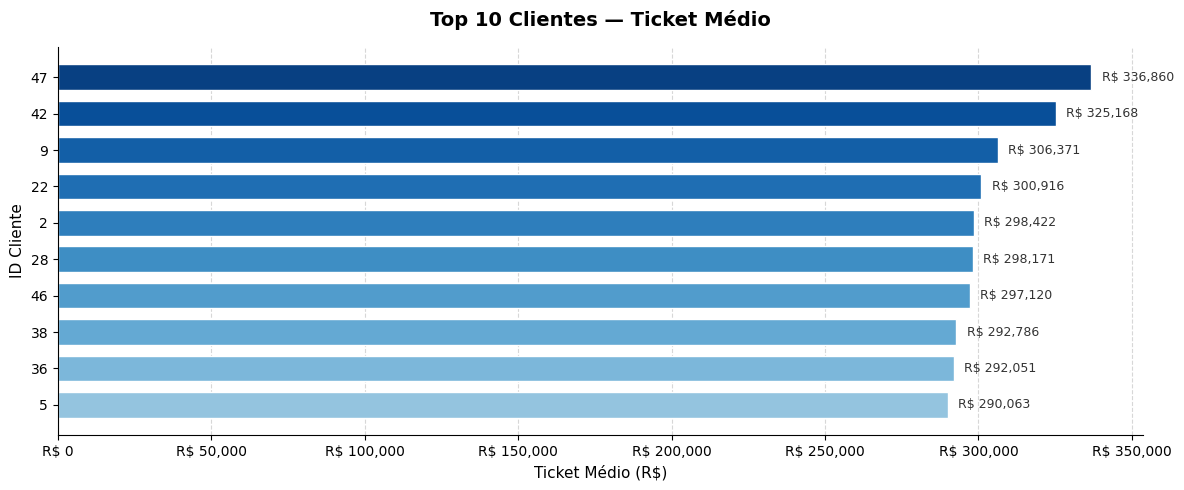

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = plt.cm.Blues([0.4 + 0.6 * i / len(top10) for i in range(len(top10))])[::-1]
bars = ax.barh(top10['id_client'].astype(str), top10['ticket_medio'], color=colors, edgecolor='white', height=0.7)

for bar, valor in zip(bars, top10['ticket_medio']):
    ax.text(
        bar.get_width() + top10['ticket_medio'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"R$ {valor:,.0f}",
        va='center', fontsize=9, color='#333333'
    )

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.set_xlabel('Ticket Médio (R$)', fontsize=11)
ax.set_ylabel('ID Cliente', fontsize=11)
ax.set_title('Top 10 Clientes — Ticket Médio', fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../docs/reports/top10_ticket_medio.png', dpi=150, bbox_inches='tight')
plt.show()

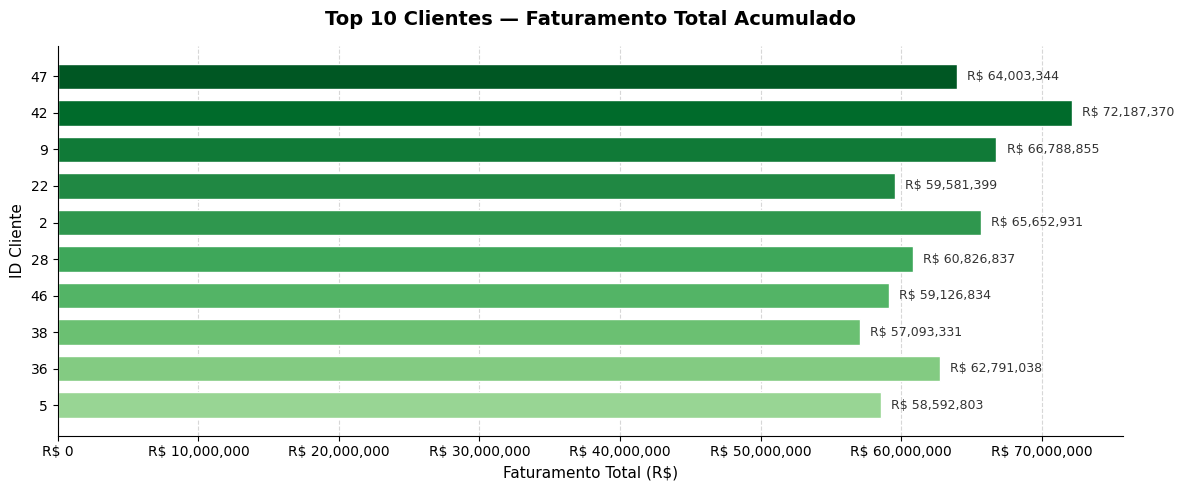

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = plt.cm.Greens([0.4 + 0.6 * i / len(top10) for i in range(len(top10))])[::-1]
bars = ax.barh(top10['id_client'].astype(str), top10['faturamento_total'], color=colors, edgecolor='white', height=0.7)

for bar, valor in zip(bars, top10['faturamento_total']):
    ax.text(
        bar.get_width() + top10['faturamento_total'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"R$ {valor:,.0f}",
        va='center', fontsize=9, color='#333333'
    )

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.set_xlabel('Faturamento Total (R$)', fontsize=11)
ax.set_ylabel('ID Cliente', fontsize=11)
ax.set_title('Top 10 Clientes — Faturamento Total Acumulado', fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../docs/reports/top10_faturamento_total.png', dpi=150, bbox_inches='tight')
plt.show()

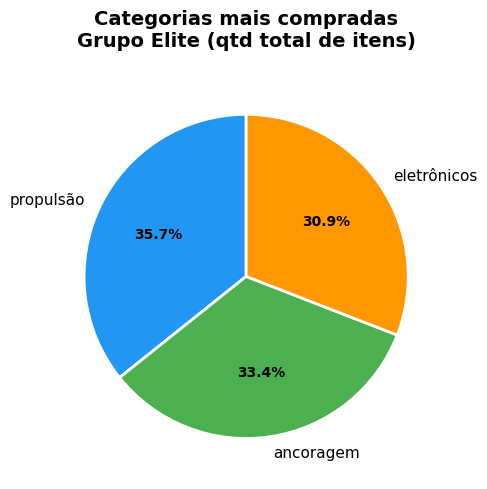

In [24]:

fig, ax = plt.subplots(figsize=(5,5))

cores_cat = ['#2196F3', '#4CAF50', '#FF9800']
wedges, texts, autotexts = ax.pie(
    categoria_dominante.values,
    labels=categoria_dominante.index,
    autopct='%1.1f%%',
    colors=cores_cat[:len(categoria_dominante)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Categorias mais compradas\nGrupo Elite (qtd total de itens)', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../docs/reports/categorias_grupo_elite.png', dpi=150, bbox_inches='tight')
plt.show()